In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import matplotlib.dates as mdates
from scipy import stats
from prophet import Prophet

In [1]:

#load parquet file
df = pd.read_parquet('taxi-dataset.parquet')

df.info()


NameError: name 'pd' is not defined

In [ ]:
#get column names
print(df.columns)

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge', 'airport_fee'],
      dtype='object')


In [ ]:
#show first 5 rows
print(df.head)

<bound method NDFrame.head of          VendorID tpep_pickup_datetime tpep_dropoff_datetime  passenger_count  \
0               1  2022-08-01 00:17:39   2022-08-01 00:19:58              1.0   
1               1  2022-08-01 00:26:06   2022-08-01 00:31:55              1.0   
2               1  2022-08-01 00:45:49   2022-08-01 00:59:29              1.0   
3               1  2022-08-01 00:05:49   2022-08-01 00:25:42              1.0   
4               1  2022-08-01 00:36:29   2022-08-01 00:51:29              1.0   
...           ...                  ...                   ...              ...   
3152672         2  2022-08-31 23:40:00   2022-08-31 23:49:00              NaN   
3152673         1  2022-08-31 23:11:41   2022-08-31 23:21:23              NaN   
3152674         2  2022-08-31 23:02:53   2022-08-31 23:12:13              NaN   
3152675         2  2022-08-31 23:54:16   2022-08-31 23:56:41              NaN   
3152676         2  2022-08-31 23:40:44   2022-08-31 23:40:53              NaN  

In [ ]:
#calculate number of null values in each column
print(df.isnull().sum())

#drop rows with null values
df = df.dropna()

VendorID                     0
tpep_pickup_datetime         0
tpep_dropoff_datetime        0
passenger_count          93174
trip_distance                0
RatecodeID               93174
store_and_fwd_flag       93174
PULocationID                 0
DOLocationID                 0
payment_type                 0
fare_amount                  0
extra                        0
mta_tax                      0
tip_amount                   0
tolls_amount                 0
improvement_surcharge        0
total_amount                 0
congestion_surcharge     93174
airport_fee              93174
dtype: int64


In [ ]:
# Set style for plots
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

In [ ]:
def load_and_prepare_data(file_path):
    """
    Load and prepare the taxi dataset
    """
    print("Loading data...")
    # Load the dataset
    df = pd.read_parquet(file_path)
    
    # Check basic information
    print("\nDataset Shape:", df.shape)
    print("\nColumns with missing values:")
    print(df.isnull().sum())

    # Dropping trips with zero/missing distance
    df = df[(df['trip_distance'] > 0)]
    
    # Convert datetime columns
    df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
    df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])
    
    # Calculate trip duration in minutes
    df['trip_duration'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds() / 60
    
    # Extract time components for time series analysis
    df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
    df['pickup_day'] = df['tpep_pickup_datetime'].dt.day_name()
    df['pickup_date'] = df['tpep_pickup_datetime'].dt.date
    df['pickup_month'] = df['tpep_pickup_datetime'].dt.month
    df['pickup_year'] = df['tpep_pickup_datetime'].dt.year
    df['pickup_dayofweek'] = df['tpep_pickup_datetime'].dt.dayofweek  # 0=Monday, 6=Sunday
    
    # Calculate tip percentage
    df['tip_percentage'] = np.where(df['fare_amount'] > 0, 
                                    (df['tip_amount'] / df['fare_amount']) * 100, 
                                    0)
    
    # Map payment types if needed (based on NYC TLC data)
    payment_type_map = {
        1: 'Credit Card',
        2: 'Cash',
        3: 'No Charge',
        4: 'Dispute',
        5: 'Unknown',
        6: 'Voided trip'
    }
    df['payment_type_desc'] = df['payment_type'].map(payment_type_map)
    
    # Handle outliers for numerical columns
    for col in ['trip_distance', 'fare_amount', 'trip_duration']:
        if col in df.columns:
            q1 = df[col].quantile(0.01)
            q3 = df[col].quantile(0.99)
            df[f'{col}_filtered'] = df[col].clip(q1, q3)
    
    return df

In [ ]:
def analyze_missing_values(df):
    """
    Analyze and visualize missing values
    """
    print("\n--- Missing Values Analysis ---")
    missing = df.isnull().sum().sort_values(ascending=False)
    missing_percent = (df.isnull().sum() / df.shape[0] * 100).sort_values(ascending=False)
    
    missing_data = pd.concat([missing, missing_percent], axis=1, keys=['Total', 'Percent'])
    print(missing_data[missing_data['Total'] > 0])
    
    # Only plot if there are missing values
    if missing_data['Total'].sum() > 0:
        plt.figure(figsize=(10, 6))
        missing_data[missing_data['Total'] > 0]['Percent'].plot(kind='bar')
        plt.title('Percentage of Missing Values by Feature')
        plt.ylabel('Percentage')
        plt.xlabel('Features')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.savefig('missing_values.png')
        print("Missing values chart saved as 'missing_values.png'")

In [ ]:
def plot_time_series_patterns(df):
    """
    Create time series plots to analyze patterns
    """
    print("\n--- Time Series Patterns Analysis ---")
    
    # Create figure with subplots
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    
    # 1. Trips by hour of day
    hourly_trips = df.groupby('pickup_hour').size()
    sns.barplot(x=hourly_trips.index, y=hourly_trips.values, ax=axes[0, 0])
    axes[0, 0].set_title('Number of Trips by Hour of Day')
    axes[0, 0].set_xlabel('Hour of Day')
    axes[0, 0].set_ylabel('Number of Trips')
    
    # 2. Trips by day of week
    day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    day_trips = df.groupby('pickup_day').size().reindex(day_order)
    sns.barplot(x=day_trips.index, y=day_trips.values, ax=axes[0, 1])
    axes[0, 1].set_title('Number of Trips by Day of Week')
    axes[0, 1].set_xlabel('Day of Week')
    axes[0, 1].set_ylabel('Number of Trips')
    axes[0, 1].set_xticklabels(axes[0, 1].get_xticklabels(), rotation=45)
    
    # 3. Average Fare by Hour
    hourly_fare = df.groupby('pickup_hour')['fare_amount'].mean()
    sns.lineplot(x=hourly_fare.index, y=hourly_fare.values, marker='o', ax=axes[1, 0])
    axes[1, 0].set_title('Average Fare by Hour of Day')
    axes[1, 0].set_xlabel('Hour of Day')
    axes[1, 0].set_ylabel('Average Fare ($)')
    
    # 4. Daily trip volume (time series)
    if len(df['pickup_date'].unique()) > 1:  # Check if we have multiple days
        daily_trips = df.groupby('pickup_date').size()
        sns.lineplot(x=daily_trips.index, y=daily_trips.values, marker='o', ax=axes[1, 1])
        axes[1, 1].set_title('Daily Trip Volume')
        axes[1, 1].set_xlabel('Date')
        axes[1, 1].set_ylabel('Number of Trips')
        axes[1, 1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
        axes[1, 1].tick_params(axis='x', rotation=45)
    else:
        axes[1, 1].set_title('Not enough date data for daily trend')
    
    plt.tight_layout()
    plt.savefig('time_series_patterns.png')
    print("Time series patterns saved as 'time_series_patterns.png'")
    
    # Heat map for hourly patterns by day of week
    plt.figure(figsize=(14, 8))
    hourly_day_trips = df.groupby(['pickup_dayofweek', 'pickup_hour']).size().unstack()
    # Reindex to ensure all days and hours are included, filling missing with 0
    all_hours = list(range(24))
    all_days = list(range(7))
    hourly_day_trips = hourly_day_trips.reindex(all_days, fill_value=0).reindex(columns=all_hours, fill_value=0)
    
    # Create the heatmap
    sns.heatmap(hourly_day_trips, cmap='viridis', annot=False, fmt='g')
    plt.title('Trip Frequency by Day of Week and Hour')
    plt.xlabel('Hour of Day')
    plt.ylabel('Day of Week')
    # Change y-axis labels to day names
    day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    plt.yticks(np.arange(7) + 0.5, day_names)
    plt.tight_layout()
    plt.savefig('day_hour_heatmap.png')
    print("Day-hour heatmap saved as 'day_hour_heatmap.png'")

In [ ]:
def analyze_trip_metrics(df):
    """
    Analyze key trip metrics: distance, duration, fare, etc.
    """
    print("\n--- Trip Metrics Analysis ---")
    
    # Create figure with subplots
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    
    # 1. Trip distance distribution
    sns.histplot(df['trip_distance_filtered'], bins=30, kde=True, ax=axes[0, 0])
    axes[0, 0].set_title('Trip Distance Distribution')
    axes[0, 0].set_xlabel('Trip Distance (miles)')
    
    # 2. Trip duration distribution
    if 'trip_duration_filtered' in df.columns:
        sns.histplot(df['trip_duration_filtered'], bins=30, kde=True, ax=axes[0, 1])
        axes[0, 1].set_title('Trip Duration Distribution')
        axes[0, 1].set_xlabel('Trip Duration (minutes)')
    
    # 3. Fare amount distribution
    sns.histplot(df['fare_amount_filtered'], bins=30, kde=True, ax=axes[1, 0])
    axes[1, 0].set_title('Fare Amount Distribution')
    axes[1, 0].set_xlabel('Fare Amount ($)')
    
    # 4. Scatter plot of Distance vs. Fare
    sns.scatterplot(x='trip_distance_filtered', y='fare_amount_filtered', 
                    data=df, alpha=0.3, ax=axes[1, 1])
    axes[1, 1].set_title('Fare vs. Distance')
    axes[1, 1].set_xlabel('Trip Distance (miles)')
    axes[1, 1].set_ylabel('Fare Amount ($)')
    
    # Calculate and display correlation
    correlation = df['trip_distance_filtered'].corr(df['fare_amount_filtered'])
    axes[1, 1].annotate(f'Correlation: {correlation:.2f}', 
                        xy=(0.05, 0.95), xycoords='axes fraction',
                        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", alpha=0.8))
    
    plt.tight_layout()
    plt.savefig('trip_metrics.png')
    print("Trip metrics analysis saved as 'trip_metrics.png'")
    
    # Payment Type Analysis
    plt.figure(figsize=(10, 6))
    payment_counts = df['payment_type_desc'].value_counts()
    plt.pie(payment_counts, labels=payment_counts.index, autopct='%1.1f%%', 
            startangle=90, shadow=True)
    plt.axis('equal')
    plt.title('Payment Method Distribution')
    plt.tight_layout()
    plt.savefig('payment_types.png')
    print("Payment types chart saved as 'payment_types.png'")
    
    # Tip Percentage Analysis
    plt.figure(figsize=(10, 6))
    valid_tips = df[df['payment_type'] == 1]['tip_percentage'].clip(0, 50)  # Focus on credit card payments
    sns.histplot(valid_tips, bins=25, kde=True)
    plt.axvline(x=valid_tips.mean(), color='r', linestyle='--', 
                label=f'Mean: {valid_tips.mean():.2f}%')
    plt.title('Tip Percentage Distribution (Credit Card Payments)')
    plt.xlabel('Tip Percentage')
    plt.legend()
    plt.tight_layout()
    plt.savefig('tip_percentage.png')
    print("Tip percentage analysis saved as 'tip_percentage.png'")


Loading data...

Dataset Shape: (3152677, 19)

Columns with missing values:
VendorID                     0
tpep_pickup_datetime         0
tpep_dropoff_datetime        0
passenger_count          93174
trip_distance                0
RatecodeID               93174
store_and_fwd_flag       93174
PULocationID                 0
DOLocationID                 0
payment_type                 0
fare_amount                  0
extra                        0
mta_tax                      0
tip_amount                   0
tolls_amount                 0
improvement_surcharge        0
total_amount                 0
congestion_surcharge     93174
airport_fee              93174
dtype: int64

--- Missing Values Analysis ---
                      Total   Percent
airport_fee           93174  2.955393
passenger_count       93174  2.955393
RatecodeID            93174  2.955393
store_and_fwd_flag    93174  2.955393
payment_type_desc     93174  2.955393
congestion_surcharge  93174  2.955393
Missing values chart sa

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: 

Time series patterns saved as 'time_series_patterns.png'
Day-hour heatmap saved as 'day_hour_heatmap.png'

--- Trip Metrics Analysis ---


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: Futur

Trip metrics analysis saved as 'trip_metrics.png'
Payment types chart saved as 'payment_types.png'


...

Tip percentage analysis saved as 'tip_percentage.png'

--- Location Analysis ---
Top pickup locations saved as 'top_pickup_locations.png'
Top dropoff locations saved as 'top_dropoff_locations.png'


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: 

Top routes saved as 'top_routes.png'

--- Time Series Decomposition ---
Time series decomposition saved as 'time_series_decomposition.png'

--- Statistical Tests ---
Trip Distance Normality Test: statistic=1440531.4567, p-value=0.0000
Trip distance is not normally distributed

Weekday vs Weekend Fare T-Test: t=-34.7923, p-value=0.0000
There is a significant difference in fares between weekdays and weekends
Mean weekday fare: $14.55
Mean weekend fare: $15.14


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


Weekday vs weekend comparison saved as 'weekday_weekend_comparison.png'

--- Summary Statistics ---
Total Trips: 3,152,677
Total Revenue: $67,952,543.91
Average Fare: $14.82
Average Distance: 5.72 miles
Average Duration: 16.98 minutes

Busiest Hour: 18:00
Busiest Day: Tuesday

Credit Card Payments: 2,353,623 (74.7%)
Cash Payments: 675,038 (21.4%)

Average Tip (Credit Card): $3.42
Average Tip Percentage: 31.0%

Missing Values Summary:
  passenger_count: 93,174 (3.0%)
  RatecodeID: 93,174 (3.0%)
  store_and_fwd_flag: 93,174 (3.0%)
  congestion_surcharge: 93,174 (3.0%)
  airport_fee: 93,174 (3.0%)
  payment_type_desc: 93,174 (3.0%)

Fare-Distance Correlation: 0.009
Fare-Duration Correlation: 0.201

EDA completed! All visualizations have been saved as PNG files.

--- Basic Statistics ---
           VendorID        tpep_pickup_datetime       tpep_dropoff_datetime  \
count  3.152677e+06                     3152677                     3152677   
mean   1.724893e+00  2022-08-16 12:12:23.061860

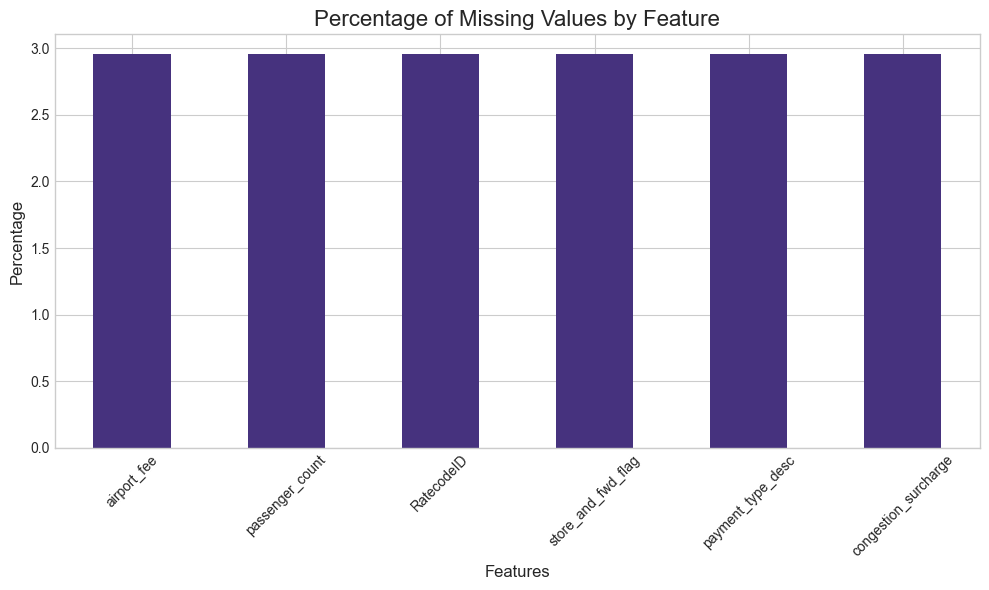

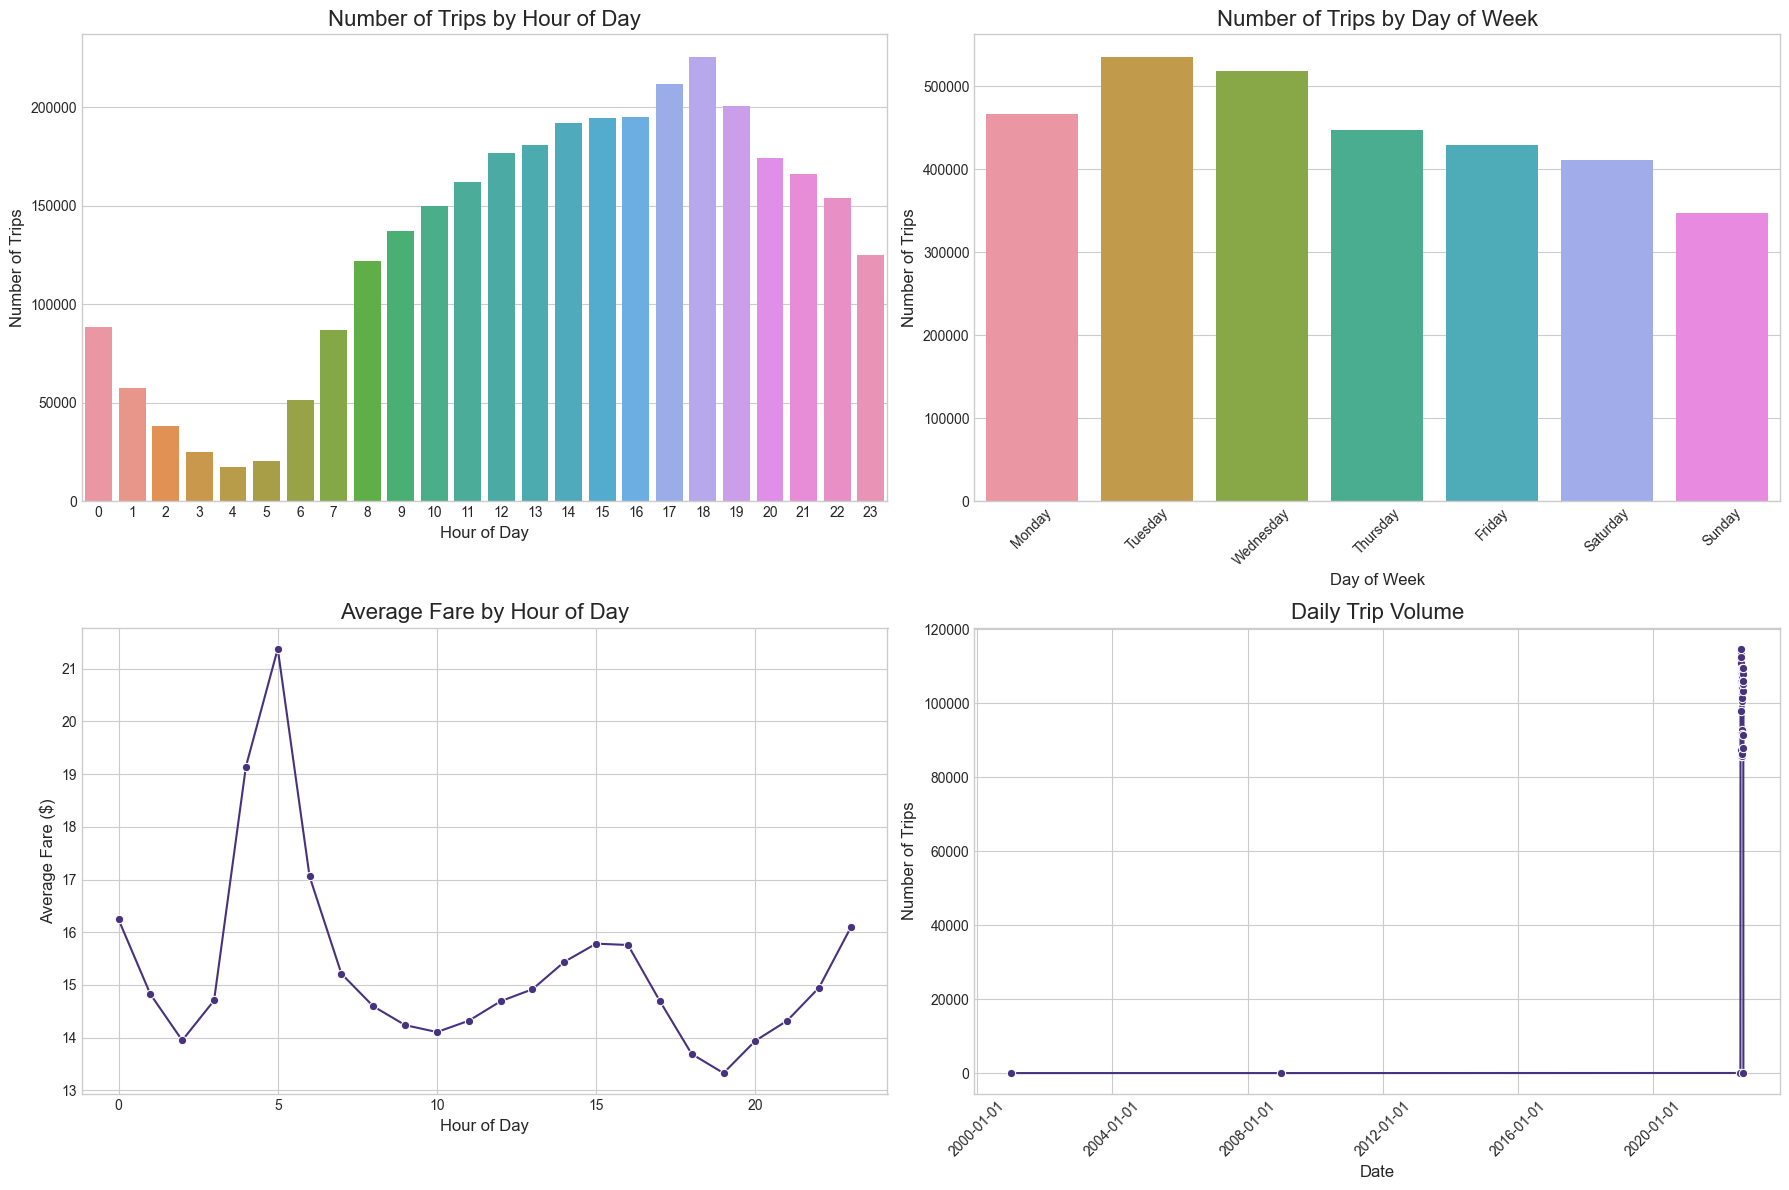

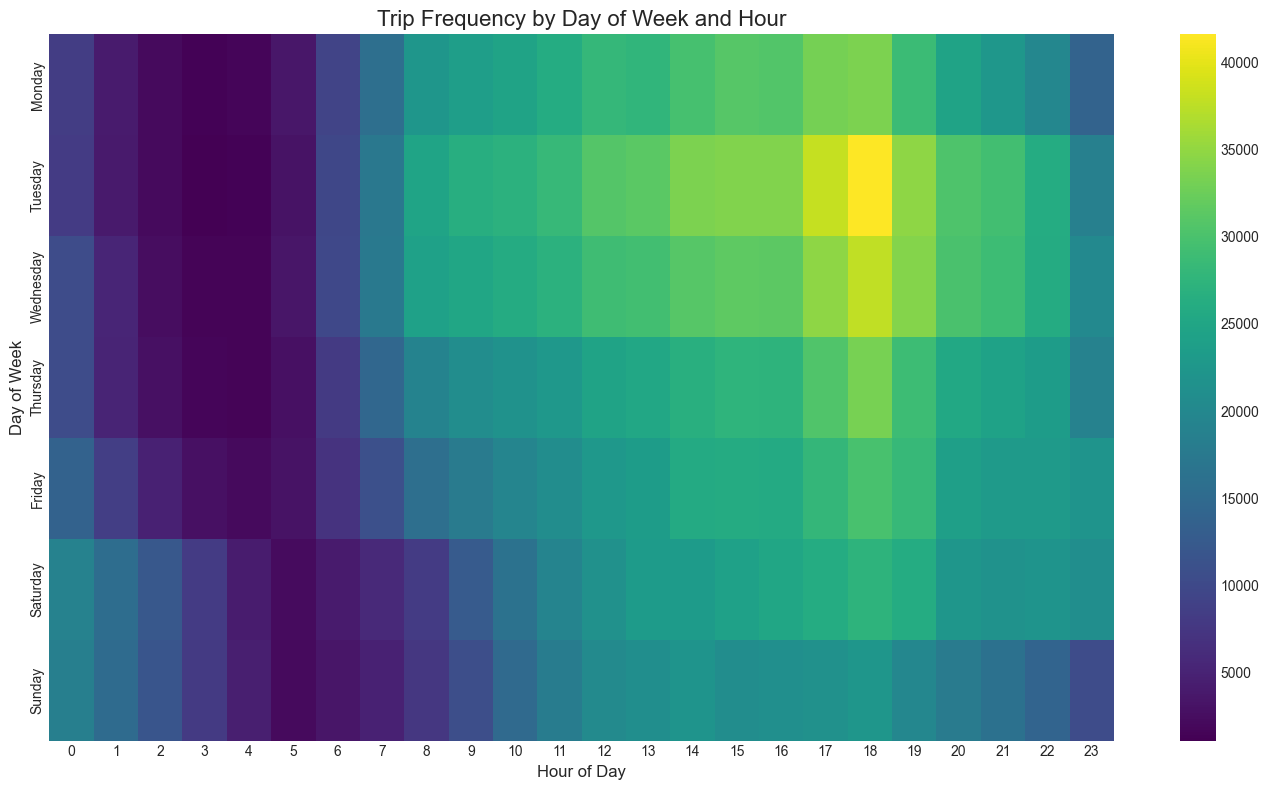

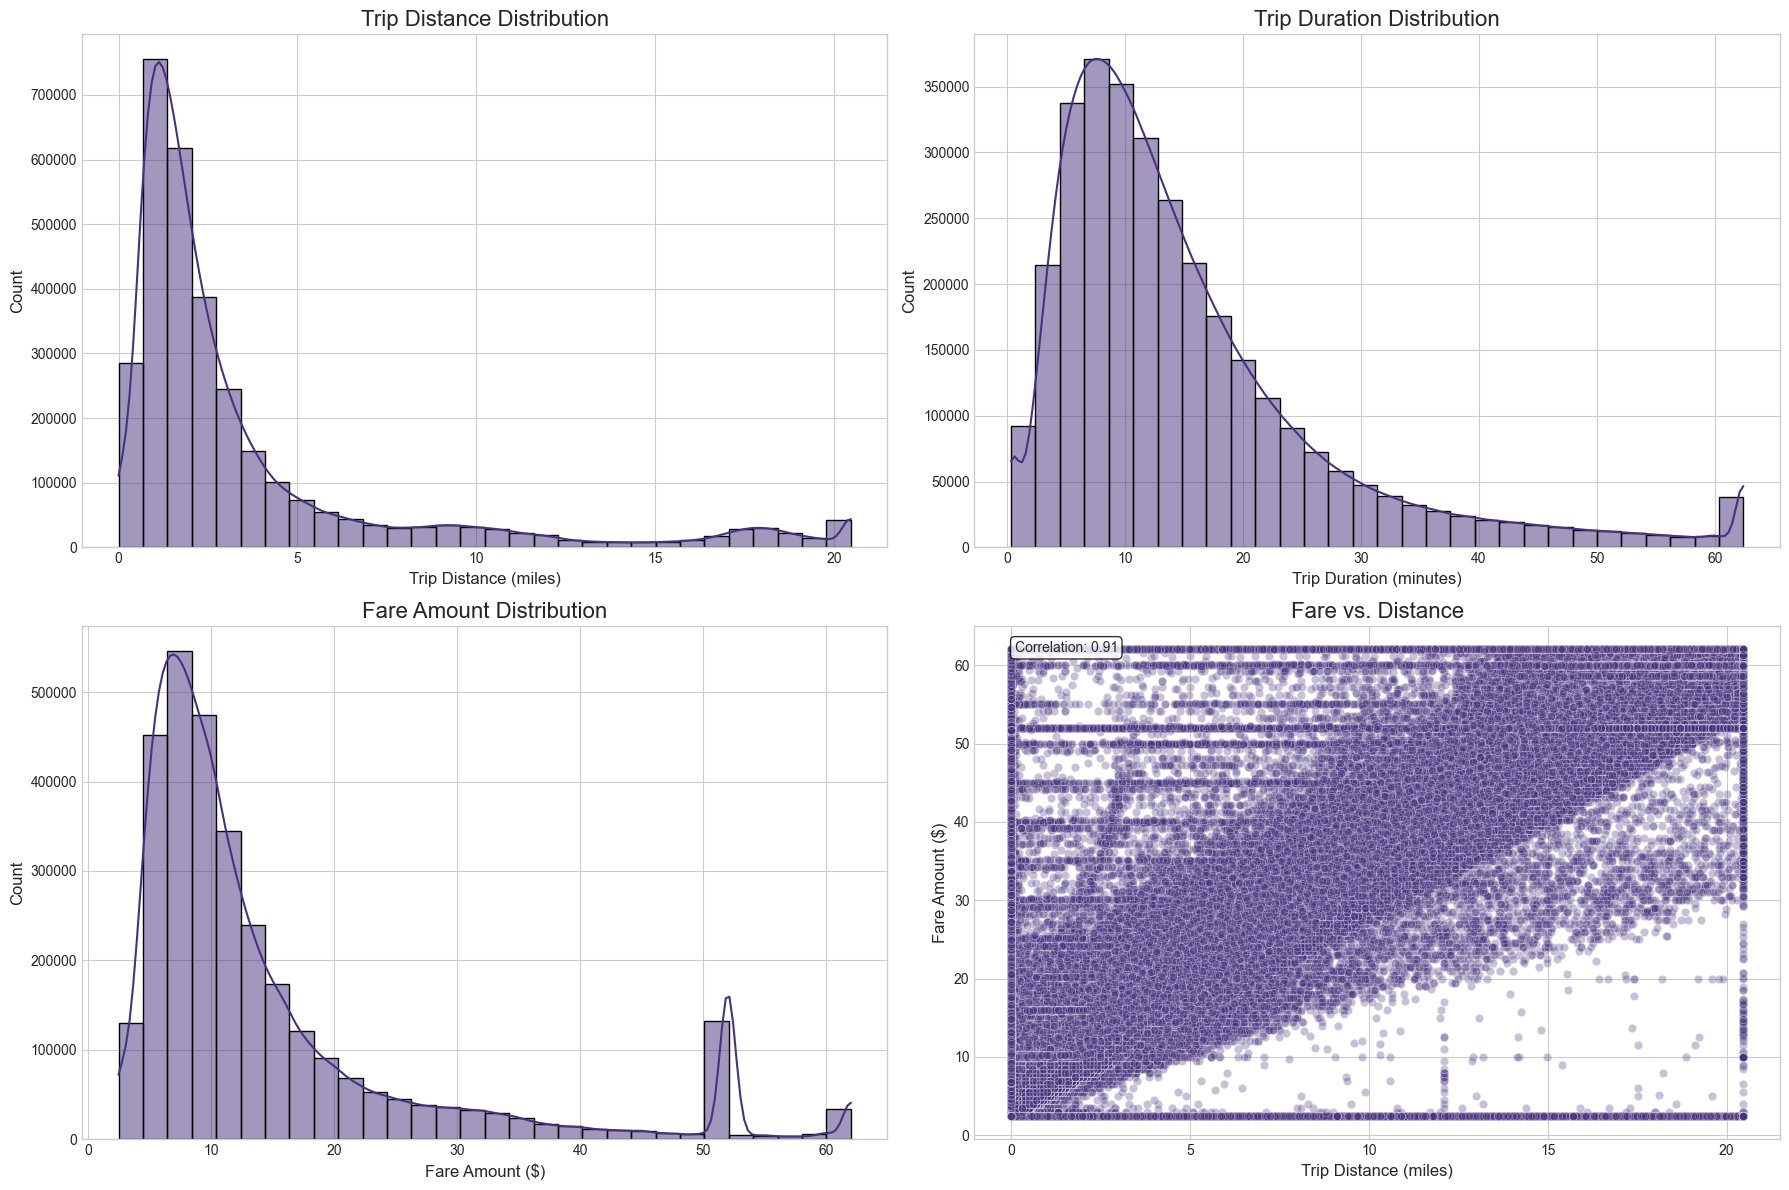

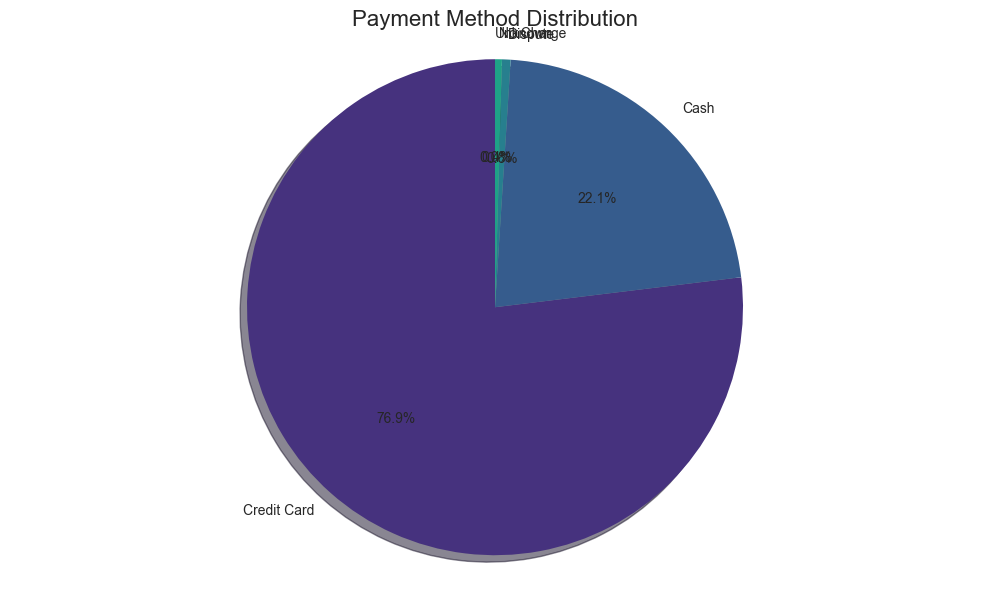

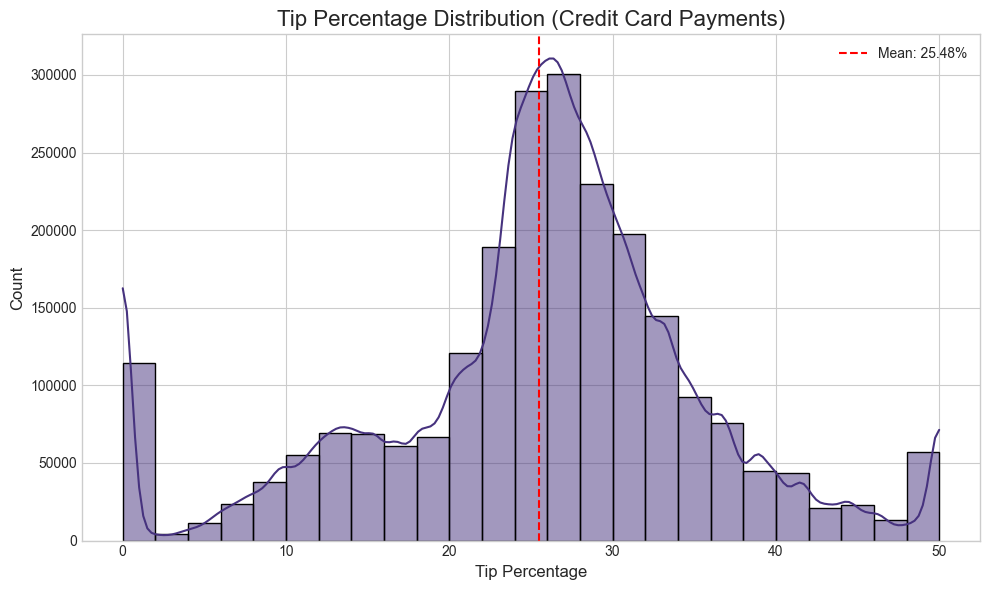

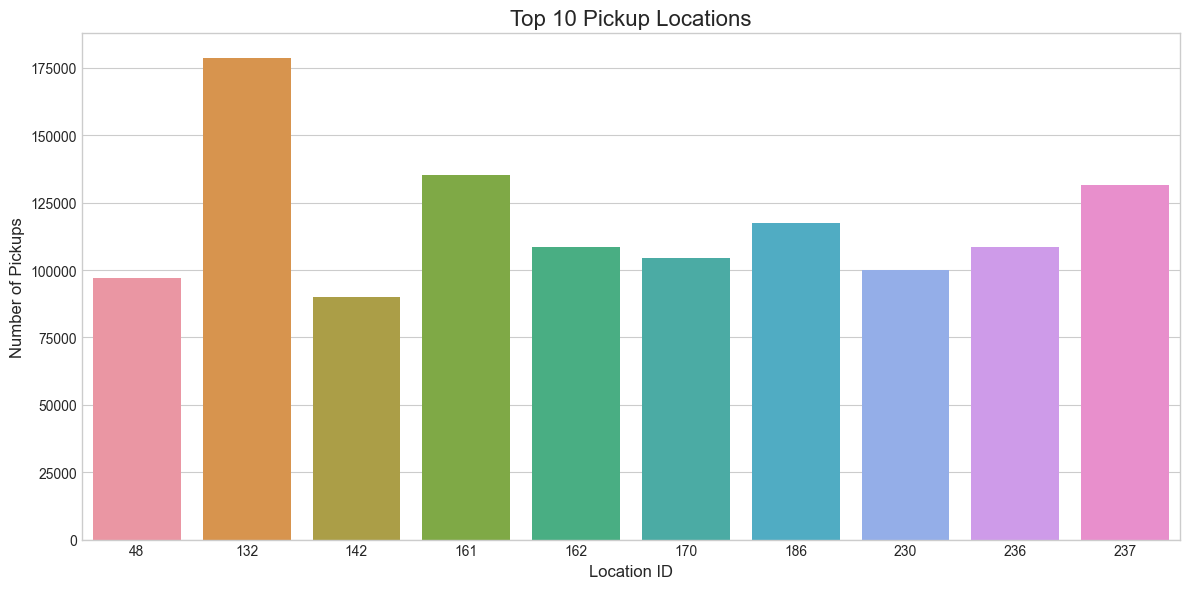

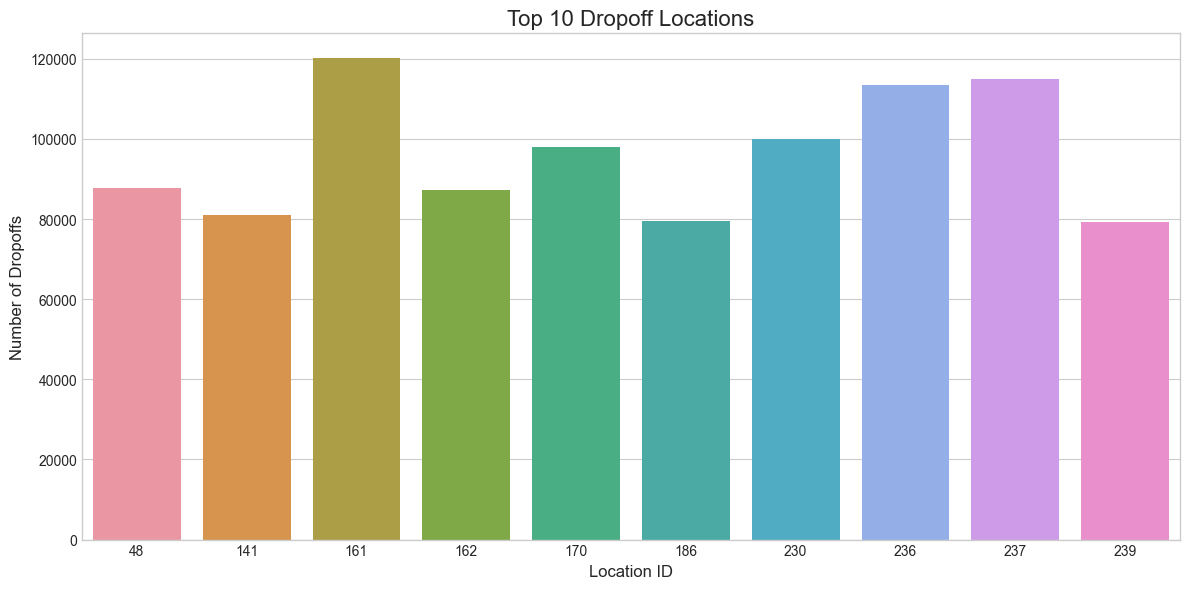

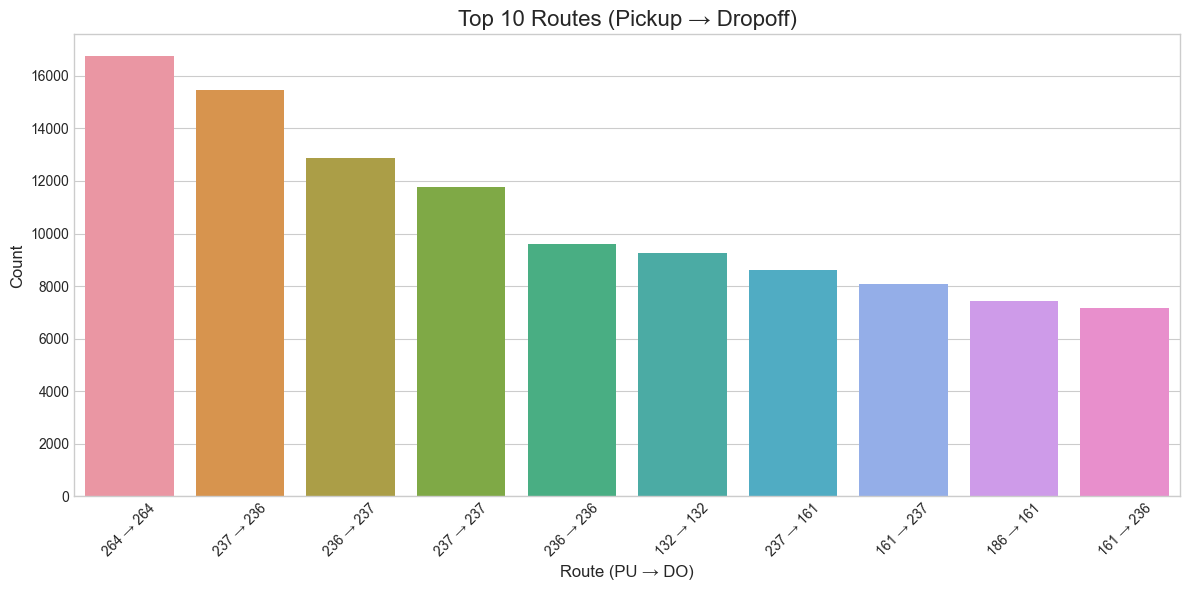

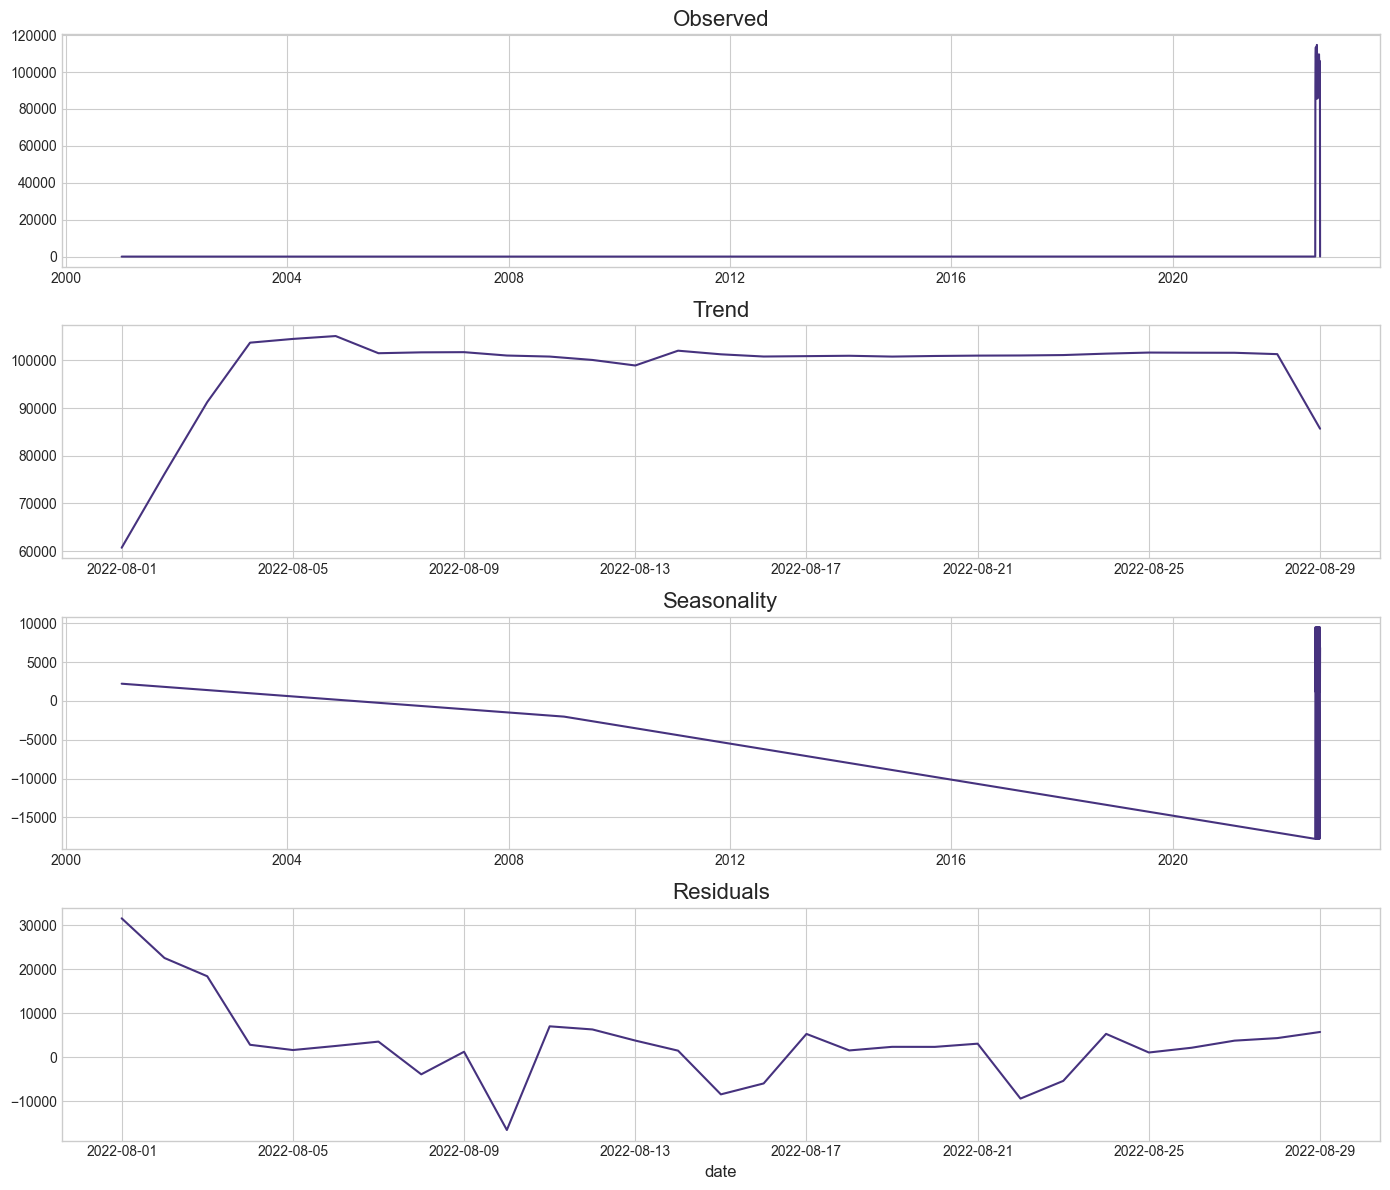

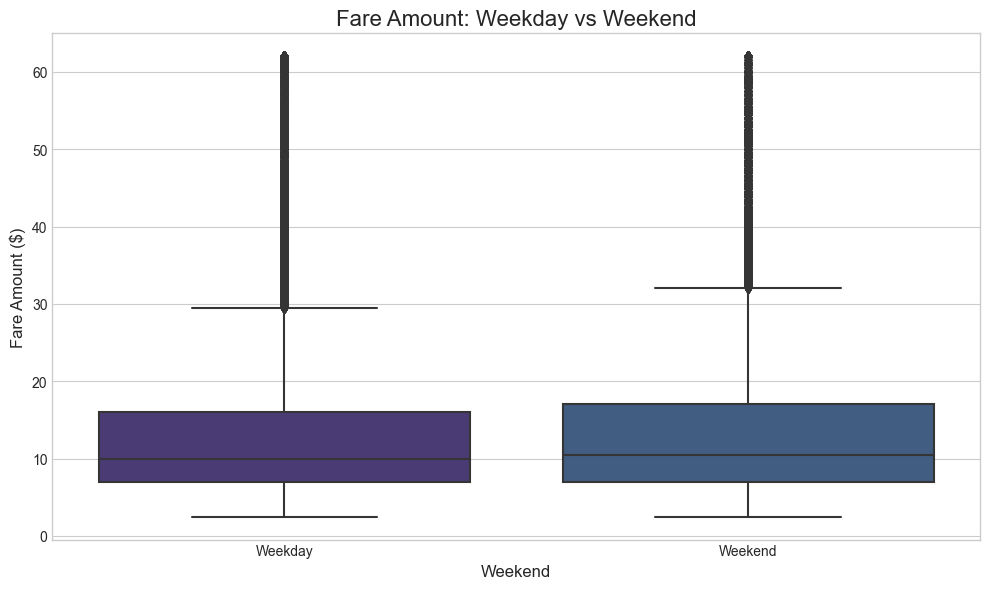

In [ ]:
def analyze_locations(df):
    """
    Analyze pickup and dropoff locations
    """
    print("\n--- Location Analysis ---")
    
    # Top pickup locations
    top_pickup = df['PULocationID'].value_counts().head(10)
    plt.figure(figsize=(12, 6))
    sns.barplot(x=top_pickup.index, y=top_pickup.values)
    plt.title('Top 10 Pickup Locations')
    plt.xlabel('Location ID')
    plt.ylabel('Number of Pickups')
    plt.tight_layout()
    plt.savefig('top_pickup_locations.png')
    print("Top pickup locations saved as 'top_pickup_locations.png'")
    
    # Top dropoff locations
    top_dropoff = df['DOLocationID'].value_counts().head(10)
    plt.figure(figsize=(12, 6))
    sns.barplot(x=top_dropoff.index, y=top_dropoff.values)
    plt.title('Top 10 Dropoff Locations')
    plt.xlabel('Location ID')
    plt.ylabel('Number of Dropoffs')
    plt.tight_layout()
    plt.savefig('top_dropoff_locations.png')
    print("Top dropoff locations saved as 'top_dropoff_locations.png'")
    
    # Most common routes (pairs of pickup-dropoff)
    routes = df.groupby(['PULocationID', 'DOLocationID']).size().reset_index(name='count')
    top_routes = routes.sort_values('count', ascending=False).head(10)
    plt.figure(figsize=(12, 6))
    sns.barplot(x=top_routes.apply(lambda x: f"{x['PULocationID']} → {x['DOLocationID']}", axis=1),
                y=top_routes['count'])
    plt.title('Top 10 Routes (Pickup → Dropoff)')
    plt.xlabel('Route (PU → DO)')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig('top_routes.png')
    print("Top routes saved as 'top_routes.png'")

def time_series_decomposition(df):
    """
    Perform time series decomposition to identify trends and seasonality
    """
    try:
        from statsmodels.tsa.seasonal import STL
        
        print("\n--- Time Series Decomposition ---")
        
        # Check if we have enough data points
        daily_trips = df.groupby('pickup_date').size()
        
        if len(daily_trips) >= 14:  # Need at least 2 weeks of data for meaningful decomposition
            # Convert to time series
            ts = daily_trips.reset_index()
            ts.columns = ['date', 'trips']
            ts.set_index('date', inplace=True)
            
            # Perform decomposition
            decomposition = STL(ts)  # Assuming weekly seasonality
            
            # Plot decomposition
            fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(14, 12))
            
            decomposition.observed.plot(ax=ax1)
            ax1.set_title('Observed')
            ax1.set_xlabel('')
            
            decomposition.trend.plot(ax=ax2)
            ax2.set_title('Trend')
            ax2.set_xlabel('')
            
            decomposition.seasonal.plot(ax=ax3)
            ax3.set_title('Seasonality')
            ax3.set_xlabel('')
            
            decomposition.resid.plot(ax=ax4)
            ax4.set_title('Residuals')
            
            plt.tight_layout()
            plt.savefig('time_series_decomposition.png')
            print("Time series decomposition saved as 'time_series_decomposition.png'")
        else:
            print("Not enough data points for time series decomposition (need at least 14 days)")
    except Exception as e:
        print(f"Unable to perform time series decomposition: {e}")
        print("Make sure statsmodels is installed: pip install statsmodels")

def statistical_tests(df):
    """
    Perform statistical tests and analysis
    """
    print("\n--- Statistical Tests ---")
    
    # Check for normality in trip distance
    stat, p = stats.normaltest(df['trip_distance_filtered'])
    print(f"Trip Distance Normality Test: statistic={stat:.4f}, p-value={p:.4f}")
    if p < 0.05:
        print("Trip distance is not normally distributed")
    else:
        print("Trip distance appears to be normally distributed")
    
    # Weekday vs Weekend comparison
    df['is_weekend'] = df['pickup_dayofweek'].isin([5, 6])  # 5=Saturday, 6=Sunday
    
    # Compare fares: weekday vs weekend
    weekday_fares = df[~df['is_weekend']]['fare_amount_filtered']
    weekend_fares = df[df['is_weekend']]['fare_amount_filtered']
    
    # T-test for fare differences
    t_stat, p_val = stats.ttest_ind(weekday_fares, weekend_fares, equal_var=False)
    print(f"\nWeekday vs Weekend Fare T-Test: t={t_stat:.4f}, p-value={p_val:.4f}")
    if p_val < 0.05:
        print("There is a significant difference in fares between weekdays and weekends")
    else:
        print("No significant difference in fares between weekdays and weekends")
    
    print(f"Mean weekday fare: ${weekday_fares.mean():.2f}")
    print(f"Mean weekend fare: ${weekend_fares.mean():.2f}")
    
    # Plot the comparison
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='is_weekend', y='fare_amount_filtered', data=df)
    plt.title('Fare Amount: Weekday vs Weekend')
    plt.xlabel('Weekend')
    plt.xticks([0, 1], ['Weekday', 'Weekend'])
    plt.ylabel('Fare Amount ($)')
    plt.tight_layout()
    plt.savefig('weekday_weekend_comparison.png')
    print("Weekday vs weekend comparison saved as 'weekday_weekend_comparison.png'")

def create_summary_report(df):
    """
    Create a summary report with key statistics
    """
    print("\n--- Summary Statistics ---")
    
    # General statistics
    total_trips = len(df)
    total_revenue = df['total_amount'].sum()
    avg_fare = df['fare_amount'].mean()
    avg_distance = df['trip_distance'].mean()
    avg_duration = df['trip_duration'].mean() if 'trip_duration' in df.columns else float('nan')
    
    print(f"Total Trips: {total_trips:,}")
    print(f"Total Revenue: ${total_revenue:,.2f}")
    print(f"Average Fare: ${avg_fare:.2f}")
    print(f"Average Distance: {avg_distance:.2f} miles")
    if not np.isnan(avg_duration):
        print(f"Average Duration: {avg_duration:.2f} minutes")
    
    # Time patterns
    busiest_hour = df.groupby('pickup_hour').size().idxmax()
    busiest_day = df.groupby('pickup_day').size().idxmax()
    
    print(f"\nBusiest Hour: {busiest_hour}:00")
    print(f"Busiest Day: {busiest_day}")
    
    # Payment statistics
    card_payments = (df['payment_type'] == 1).sum()
    card_payment_pct = card_payments / total_trips * 100
    cash_payments = (df['payment_type'] == 2).sum()
    cash_payment_pct = cash_payments / total_trips * 100
    
    print(f"\nCredit Card Payments: {card_payments:,} ({card_payment_pct:.1f}%)")
    print(f"Cash Payments: {cash_payments:,} ({cash_payment_pct:.1f}%)")
    
    # Tip statistics (for credit card payments only)
    card_trips = df[df['payment_type'] == 1]
    avg_tip = card_trips['tip_amount'].mean()
    avg_tip_pct = card_trips['tip_percentage'].mean()
    
    print(f"\nAverage Tip (Credit Card): ${avg_tip:.2f}")
    print(f"Average Tip Percentage: {avg_tip_pct:.1f}%")
    
    # Missing data summary
    missing_data = df.isnull().sum()
    print("\nMissing Values Summary:")
    for col, count in missing_data[missing_data > 0].items():
        print(f"  {col}: {count:,} ({count/len(df)*100:.1f}%)")
    
    # Key correlations
    if 'trip_distance' in df.columns and 'fare_amount' in df.columns:
        fare_dist_corr = df['trip_distance'].corr(df['fare_amount'])
        print(f"\nFare-Distance Correlation: {fare_dist_corr:.3f}")
    
    if 'trip_duration' in df.columns and 'fare_amount' in df.columns:
        fare_time_corr = df['trip_duration'].corr(df['fare_amount'])
        print(f"Fare-Duration Correlation: {fare_time_corr:.3f}")

def perform_full_eda(file_path):
    """
    Perform full exploratory data analysis
    """
    # Load and prepare data
    df = load_and_prepare_data(file_path)
    
    # Analyze missing values
    analyze_missing_values(df)
    
    # Analyze time series patterns
    plot_time_series_patterns(df)
    
    # Analyze trip metrics
    analyze_trip_metrics(df)
    
    # Analyze locations
    analyze_locations(df)
    
    # Time series decomposition
    time_series_decomposition(df)
    
    # Statistical tests
    statistical_tests(df)
    
    # Create summary report
    create_summary_report(df)
    
    print("\nEDA completed! All visualizations have been saved as PNG files.")
    return df

# Example usage
if __name__ == "__main__":
    # Replace with your actual file path
    file_path = "taxi-dataset.parquet"
    
    # Run the full EDA
    df = perform_full_eda(file_path)
    
    # Display basic stats
    print("\n--- Basic Statistics ---")
    print(df.describe())